# Lab 3: Decision Tree Classification
## Training, Evaluation & Overfitting — Telco Customer Churn

**Name:**
**Student ID:**
**Section:**
**GitHub Profile:**
**Kaggle Profile:**
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [27]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

**Answer 2:**


The objective is to predict whether a telecom customer will leave the service (churn) based on their usage patterns and account details. This enables the business to identify key reasons for customer drop-off, fix service gaps, and take proactive steps to retain valuable customers.


In [28]:
# Task 1 — load and verify the cleaned dataset
df=pd.read_csv("/kaggle/input/datasets/azharalisoomro/telco-customer-churn-cleaned/clean_churn.csv")
print(df.shape)
print(df.info())
print(df['Churn'].value_counts())

(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [29]:
# Additional verification if needed (dtypes, target check, etc.)
# Additional verification if needed (dtypes, target check, etc.)

print(df.shape)
print(df.info())

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df.isnull().sum())
null_counts=df.isnull().sum()
print(null_counts)

#df.head()

(7043, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null

---

## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [30]:
# Task 3 — define y and X
y = df["Churn"]

X = df.drop(columns=["Churn"])




In [31]:
# Task 4 — encode categorical columns in X
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.dtypes)

(7043, 30)
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
Streaming

**Answer 4 (encoding method & justification):**

I used **one-hot encoding with `pd.get_dummies()`** to convert categorical features into numerical values. I used `drop_first=True` to avoid unnecessary redundant columns while keeping the required information for the ML model.


In [32]:
# Task 5 — confirm X is fully numeric with no missing values
print(X.dtypes)
print("\nMissing values:")
print(X.isnull().sum().sum())

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

---

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [33]:
# Task 6 — train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
# Task 7 — report shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


### Answer 6: Why `stratify=y`?

> `stratify=y` keeps the same proportion of churned and non-churned customers in both the training and testing sets. This is important because the `Churn` target variable is imbalanced.


---

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [35]:
# Task 8 — train baseline Decision Tree and predict on train/test
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Training predictions:", y_train_pred[:10])
print("Testing predictions:", y_test_pred[:10])

Training predictions: ['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No']
Testing predictions: ['No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No']


In [36]:
# Task 9 — check the fitted tree's depth
print("Tree depth:", model.get_depth())

Tree depth: 23


### Answer 9

 The Decision Tree grew to a depth of **23** on its own. This is quite deep, which suggests that the unrestricted tree may be learning very specific patterns in the training data and could potentially overfit.


## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [37]:
# Task 10 — compute accuracy, precision, recall, F1 on the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, pos_label="Yes")
recall = recall_score(y_test, y_test_pred, pos_label="Yes")
f1 = f1_score(y_test, y_test_pred, pos_label="Yes")

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})

print(results)

      Metric     Score
0   Accuracy  0.726047
1  Precision  0.483784
2     Recall  0.478610
3   F1 Score  0.481183


**Task 10 — Results Table**

    Metric     Score
0   Accuracy  0.726047
1  Precision  0.483784
2     Recall  0.478610
3   F1 Score  0.481183

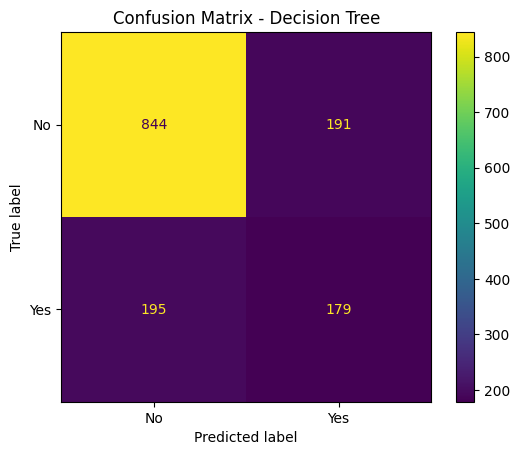

[[844 191]
 [195 179]]


In [38]:
# Task 11 — plot the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["No", "Yes"]
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Print the actual values
print(cm)

**Answer 11 (churners correctly caught vs. missed):**


The model correctly caught 179 actual churners as churners. However, it missed 195 actual churners by predicting that they would not churn. This shows that the model detected only about 47.86% of the actual churners.

**Answer 12 (which metric(s) do you trust most, and why):**

I trust Recall and F1-score more than Accuracy for this churn prediction problem. The dataset is imbalanced, so Accuracy can appear high even if the model fails to identify many churners. Recall is important because it shows how many actual churners the model successfully catches, while F1-score provides a balance between Precision and Recall. In this case, the relatively low Recall and F1-score show that the model needs improvement.

---

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train the baseline Decision Tree
baseline_tree = DecisionTreeClassifier(random_state=42)

baseline_tree.fit(X_train, y_train)

# Check training and test accuracy
train_accuracy = accuracy_score(y_train, baseline_tree.predict(X_train))
test_accuracy = accuracy_score(y_test, baseline_tree.predict(X_test))

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Accuracy Gap:", train_accuracy - test_accuracy)

Training Accuracy: 0.9980475683351083
Test Accuracy: 0.7260468417317246
Accuracy Gap: 0.2720007266033837


Answer 13

You can write:

The training accuracy is 99.80%, while the test accuracy is 72.60%, giving an accuracy gap of about 27.20 percentage points. This is a large gap and suggests that the baseline Decision Tree is overfitting. The model has learned the training data very closely, including patterns that do not generalize well to unseen data.

In [40]:
# Task 14 — loop over max_depth values, record train/test accuracy
depths = [2, 3, 4, 5, 6, 8, 10, None]
# YOUR CODE HERE
results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results.append([depth, train_acc, test_acc])

results_df = pd.DataFrame(
    results,
    columns=["max_depth", "train_accuracy", "test_accuracy"]
)

results_df

,max_depth,train_accuracy,test_accuracy
0,2.0,0.791090,0.787083
1,3.0,0.791090,0.787083
2,4.0,0.792510,0.795600
3,5.0,0.802272,0.794180
4,6.0,0.810614,0.800568
5,8.0,0.835818,0.782825
6,10.0,0.872737,0.755145
7,NaN,0.998048,0.726047


**Task 14 — Results Table**

| max_depth | Train Accuracy | Test Accuracy |
|---|---|---|
| 2 | | |
| 3 | | |
| 4 | | |
| 5 | | |
| 6 | | |
| 8 | | |
| 10 | | |
| None | | |

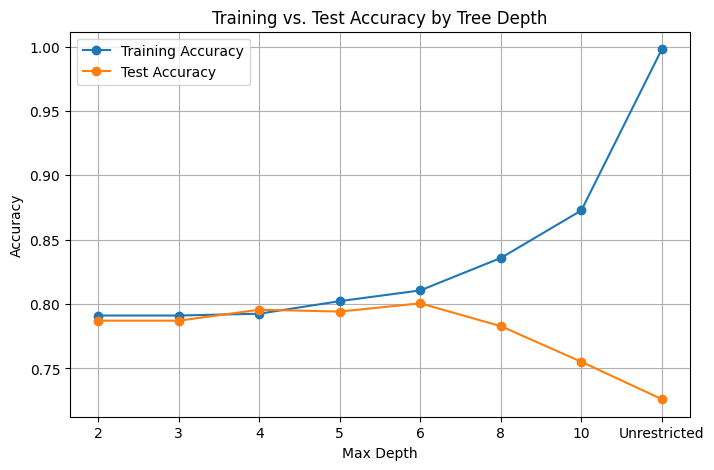

In [41]:
# Task 15 — plot train vs. test accuracy against max_depth

# Replace None with a label for plotting
depth_labels = ["2", "3", "4", "5", "6", "8", "10", "Unrestricted"]

plt.figure(figsize=(8, 5))

plt.plot(
    depth_labels,
    results_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_labels,
    results_df["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Training vs. Test Accuracy by Tree Depth")
plt.legend()
plt.grid(True)

plt.show()

**Answer 15 (where overfitting starts, and why):**
_(your answer here)_

---

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

Answer 16:
I selected max_depth = 6 because it provides the best balance between training and test accuracy. At this depth, the training accuracy is 81.06% and the test accuracy is 80.06%, giving a very small gap of about 1 percentage point. Deeper trees increase training accuracy but reduce test accuracy, which indicates overfitting.

In [42]:
# Task 17 — retrain at chosen depth and report full evaluation metrics

final_tree = DecisionTreeClassifier(max_depth=6, random_state=42)

final_tree.fit(X_train, y_train)

y_pred_final = final_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final, pos_label="Yes")
recall = recall_score(y_test, y_pred_final, pos_label="Yes")
f1 = f1_score(y_test, y_pred_final, pos_label="Yes")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Accuracy: 0.8005677785663591
Precision: 0.6666666666666666
Recall: 0.49732620320855614
F1 Score: 0.5696784073506891

Confusion Matrix:
[[942  93]
 [188 186]]


| **Metric** | **Baseline (unrestricted)** | **Chosen Model (max_depth = 6)** |
| ---------- | --------------------------: | -------------------------------: |
| Accuracy   |                      72.60% |                       **80.06%** |
| Precision  |                      48.38% |                       **66.67%** |
| Recall     |                      47.86% |                       **49.73%** |
| F1-score   |                        ~48% |                       **56.97%** |


---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

Partner_Yes                              0.000000
InternetService_No                       0.000000
OnlineBackup_No internet service         0.000000
StreamingMovies_No internet service      0.000000
StreamingTV_Yes                          0.000000
TechSupport_No internet service          0.000000
DeviceProtection_Yes                     0.000000
DeviceProtection_No internet service     0.000000
PaymentMethod_Mailed check               0.000000
PhoneService_Yes                         0.000892
PaymentMethod_Credit card (automatic)    0.002319
StreamingMovies_Yes                      0.002855
SeniorCitizen                            0.003691
gender_Male                              0.005389
Dependents_Yes                           0.005726
PaperlessBilling_Yes                     0.006023
OnlineSecurity_Yes                       0.006069
MultipleLines_No phone service           0.006455
OnlineBackup_Yes                         0.007013
TechSupport_Yes                          0.011892


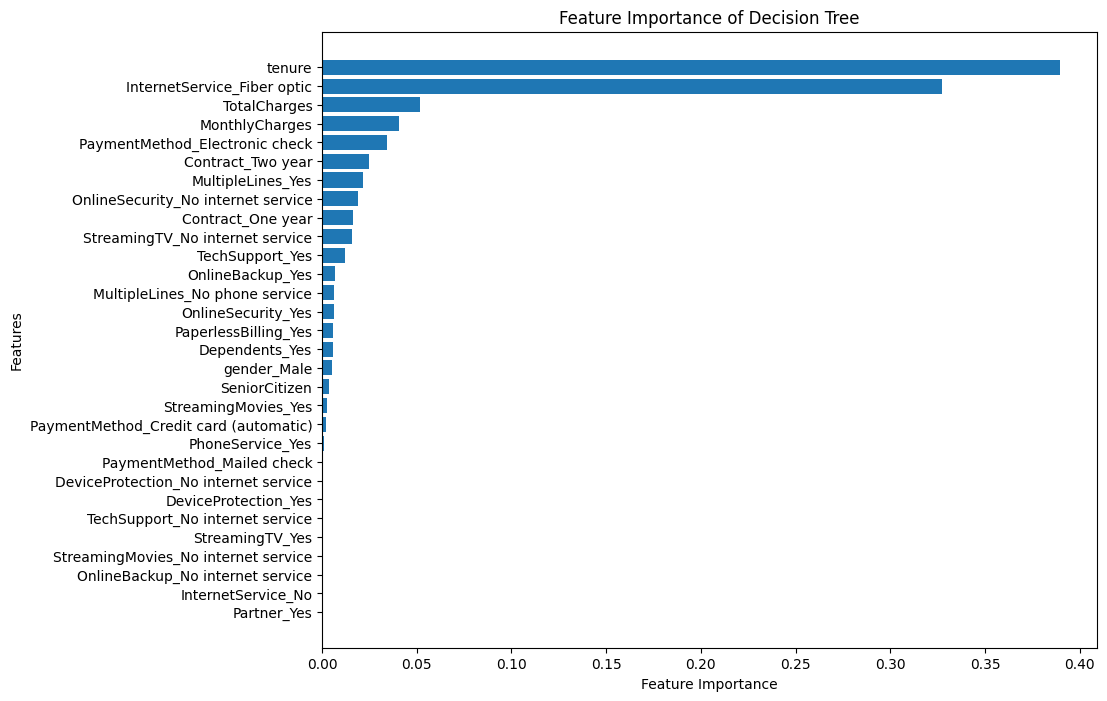

In [43]:
# Task 18 — Feature importance

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances
importances = final_tree.feature_importances_

# Create a Series with feature names
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values()

# Display feature importance
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.index, feature_importance.values)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance of Decision Tree")

plt.show()

Based on your actual output, the top 5 features are:

tenure: 0.389640
InternetService_Fiber optic: 0.327372
TotalCharges: 0.051916
MonthlyCharges: 0.040819
PaymentMethod_Electronic check: 0.034488
Answer 18

The 5 most important features are tenure, InternetService_Fiber optic, TotalCharges, MonthlyCharges, and PaymentMethod_Electronic check. Tenure and Fiber optic internet service are by far the most important features, with importance scores of 0.3896 and 0.3274 respectively. This suggests that the tree relies heavily on customer tenure and whether the customer uses fiber optic internet when making churn predictions.

---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

### Answer 19

 **The feature importance results generally agree with the EDA findings from Lab 2, particularly for tenure, MonthlyCharges, and InternetService. The model shows that tenure and Fiber optic internet service are the strongest predictors of churn, which supports the earlier observation that customers with shorter tenure and certain internet service types were more likely to churn.**


---

**Answer 20 — Conclusion:**
The Decision Tree model initially overfit the training data, achieving 99.80% training accuracy but only 72.60% test accuracy. Limiting the tree to max_depth = 6 reduced overfitting and improved test accuracy to 80.06%, with tenure and Fiber optic internet service being the most important features.

**Answer 21 — Next steps:**
The next step would be to further improve the model by tuning hyperparameters such as max_depth, min_samples_split, and min_samples_leaf, and comparing the Decision Tree with other models such as Random Forest or Logistic Regression. Since recall for churners is only 49.73%, improving the model's ability to identify customers likely to churn should be a priority.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Verification
- [ ] Section 3 — Feature/Target Preparation (with encoding justified)
- [ ] Section 4 — Train/Test Split
- [ ] Section 5 — Baseline Decision Tree
- [ ] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [ ] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [ ] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [ ] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [ ] Section 10 — Interpretation (connected to Lab 2's EDA)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted